# Regime-Shift: macro-aware tactical asset allocation

A Hidden Markov Model labels market regimes; convex optimization sets the portfolio stance per
regime; an expanding walk-forward with a one-day execution lag and 7.5 bps of cost decides whether
any of it survives contact with out-of-sample data.

**It does not.** This notebook runs the pipeline top to bottom and shows why: the HMM finds
*volatility* regimes, and on US 2016-2023 volatility carries no directional information. A
two-line volatility rule, costed identically, beats it.

Every function called here lives in `src/regime_shift/`. The notebook is the narrative, not the
implementation.

In [1]:
import warnings

import numpy as np
import pandas as pd

from regime_shift.backtest import run_backtest
from regime_shift.benchmarks import equal_weight, sixty_forty, vol_rule_regimes
from regime_shift.config import load_config
from regime_shift.data import build_master
from regime_shift.features import build_features
from regime_shift.metrics import bootstrap_ci, deflated_sharpe, optimal_block_length, summary
from regime_shift.plots import equity_drawdown, regime_overlay, transition_heatmap
from regime_shift.regime import RegimeModel, bic_sweep, dwell_times
from regime_shift.walkforward import run_walk_forward

warnings.filterwarnings("ignore")  # hmmlearn is noisy against numpy 2.5
pd.set_option("display.width", 200)

cfg = load_config()
cfg.hmm, cfg.walkforward, cfg.costs_bps, cfg.weight_cap

(HMMCfg(n_states=3, covariance_type='diag', n_iter=200, tol=0.01),
 WalkForward(min_train=252, test_size=63, step=63),
 7.5,
 0.6)

## 1. Data

Adjusted prices from Yahoo, cached to `data/` on first pull so every later run is offline. Macro
comes keyless from FRED and is forward-filled then lagged one day, so a row never sees a figure
published after its own close. If FRED is unreachable the master simply arrives without macro
columns rather than failing.

Asset columns are **log** returns.

In [2]:
master = build_master(cfg.universes["us"], cfg.dates["start"], cfg.dates["end"])
print(master.shape, list(master.columns))
master.tail(3)

(2263, 4) ['equity_ret', 'bond_ret', 'gold_ret', 'vix']


Ticker,equity_ret,bond_ret,gold_ret,vix
Date,,,,
2023-12-27,0.001807,0.017564,0.004528,12.43
2023-12-28,0.000378,-0.007290,-0.005832,12.47
2023-12-29,-0.002899,-0.009061,-0.001568,12.45


## 2. Causal features

Multi-window momentum (direction), realized volatility (stress), VIX and its change. Every rolling
window is right-aligned, so a feature at time t uses only rows at or before t.

Standardization is deliberately **not** done here. It happens inside each walk-forward fold using
train-only statistics, which is the difference between a leak-proof pipeline and a flattering
one.

In [3]:
feats = build_features(master, cfg)
print(feats.shape)
feats.tail(3)

(2138, 9)


Ticker,mom_5,mom_21,mom_63,mom_126,vol_5,vol_21,vol_63,vix,vix_chg
Date,,,,,,,,,
2023-12-27,0.003511,0.051381,0.115978,0.095520,0.138927,0.091169,0.120908,12.43,-0.559999
2023-12-28,0.017843,0.050769,0.110575,0.091964,0.056450,0.091317,0.120675,12.47,0.040000
2023-12-29,0.005506,0.048574,0.110106,0.077333,0.041648,0.092570,0.120745,12.45,-0.020000


## 3. Leak-proof walk-forward

Per fold: fit the scaler on train rows only, re-fit the HMM on scaled train, then decode the test
block with a **causal forward filter** carrying the train history forward. Whole-sequence Viterbi
would let a test day's label depend on later test days, so it is never used for decisions.

Labels are canonical: 0 is the calmest state, ascending to the most turbulent, and that ordering
is recomputed from train data in every fold so the labels stay comparable across refits.

In [4]:
regimes = run_walk_forward(feats, cfg)
oos = regimes.index
print(f"OOS {oos[0].date()} -> {oos[-1].date()}  n={len(oos)}")
print("label counts:", regimes.value_counts().sort_index().to_dict())
print("mean dwell (days):", {k: round(v, 1) for k, v in dwell_times(regimes.to_numpy()).items()})

OOS 2016-07-05 -> 2023-12-29  n=1886
label counts: {0: 666, 1: 841, 2: 379}
mean dwell (days): {0: 26.6, 1: 21.0, 2: 22.3}


## 4. The diagnostic that decides everything

Before backtesting, ask the only question that matters: **does the label predict the return we
actually earn?** The label is read at the close of t and the position it sets earns the return of
t+1, so that is the lag to measure at.

In [5]:
fwd = np.expm1(master.shift(-1)).loc[oos]
rows = []
for label, grp in fwd.groupby(regimes):
    r = grp["equity_ret"].dropna()
    rows.append({
        "label": label,
        "days": len(r),
        "eq_ann_ret": (1 + r).prod() ** (252 / len(r)) - 1,
        "eq_ann_vol": r.std(ddof=1) * np.sqrt(252),
        "eq_sharpe": r.mean() / r.std(ddof=1) * np.sqrt(252),
        "vix_mean": master.loc[grp.index, "vix"].mean(),
    })
pd.DataFrame(rows).set_index("label").round(3)

,days,eq_ann_ret,eq_ann_vol,eq_sharpe,vix_mean
label,,,,,
0,665,0.109,0.087,1.229,13.029
1,841,0.147,0.156,0.955,19.299
2,379,0.161,0.322,0.626,28.110


Volatility rises monotonically with the label, exactly as designed. **Return rises with it
too**, which is the opposite of what the strategy assumes. De-risking on the Crisis label sells the
highest-returning days, because the rebounds of April 2020 and late 2022 were as volatile as the
crashes that preceded them.

The BIC sweep says the same thing from the likelihood side: it keeps improving as states are
added, which is what happens when a mixture is fitting a fat-tailed continuum rather than
recovering discrete states.

In [6]:
from sklearn.preprocessing import StandardScaler

scaled = StandardScaler().fit_transform(feats.to_numpy(dtype=float))
bic = bic_sweep(scaled, covariance_type=cfg.hmm.covariance_type, n_iter=cfg.hmm.n_iter,
                tol=cfg.hmm.tol, random_state=cfg.seed)
{k: round(v) for k, v in bic.items()}

{2: 39821, 3: 34354, 4: 31349, 5: 29458}

## 5. Portfolio construction and costs

Per regime: Bull takes max-Sharpe (Schaible transform, since a ratio is not convex), Bear takes
minimum variance, Crisis takes minimum variance with equity hard-capped. Covariance is Ledoit-Wolf
shrunk and expected returns are pulled toward the grand mean, because raw sample moments blow up
any optimizer.

Weights decided at the close of t earn t+1's return. Between trades the book drifts, so a
non-rebalance day has exactly zero turnover and zero cost. **Benchmarks run through the same
engine**, so the comparison is like for like.

In [7]:
books = {
    "hmm_vol_ranked": run_backtest(regimes, master, cfg),
    "hmm_return_ranked": run_backtest(
        run_walk_forward(feats, cfg, rank_col="mom_21", rank_sign=-1.0).loc[oos], master, cfg),
    "vol_rule_ablation": run_backtest(vol_rule_regimes(master, cfg).loc[oos], master, cfg),
    "60_40": sixty_forty(master, oos, cfg),
    "equal_weight": equal_weight(master, oos, cfg),
}
pd.DataFrame({k: summary(v) for k, v in books.items()}).T.round(3)

,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,psr,turnover_ann,cost_drag_ann
hmm_vol_ranked,0.049,0.096,0.542,0.765,-0.287,0.170,0.930,4.188,0.003
hmm_return_ranked,0.057,0.097,0.620,0.875,-0.285,0.200,0.954,3.769,0.003
vol_rule_ablation,0.098,0.103,0.958,1.369,-0.219,0.446,0.995,3.612,0.003
60_40,0.075,0.115,0.690,0.956,-0.276,0.273,0.969,0.409,0.000
equal_weight,0.059,0.096,0.650,0.921,-0.230,0.258,0.961,0.421,0.000


The HMM books lose to both static benchmarks and to their own no-HMM ablation, while paying
roughly ten times the turnover of 60/40.

## 6. Deflation

A Sharpe reported once, from one strategy out of several tried, is biased upward. The
probabilistic Sharpe corrects for skew, fat tails and sample length; the deflated Sharpe further
charges for how many variants were searched. The confidence interval uses a stationary bootstrap
with the block length read off the data rather than guessed.

In [8]:
for name in ("hmm_vol_ranked", "hmm_return_ranked", "vol_rule_ablation"):
    r = books[name]["ret_net"]
    lo, hi = bootstrap_ci(r, n_boot=2000)
    print(f"{name:20s} block={optimal_block_length(r):5.1f}d  "
          f"CI=({lo:6.3f}, {hi:6.3f})  DSR@4trials={deflated_sharpe(r, 4, 0.4):.3f}")

hmm_vol_ranked       block=  2.9d  CI=(-0.211,  1.263)  DSR@4trials=0.630
hmm_return_ranked    block=  2.9d  CI=(-0.127,  1.337)  DSR@4trials=0.706


vol_rule_ablation    block=  2.2d  CI=( 0.238,  1.652)  DSR@4trials=0.928


Only the simple rule has an interval that excludes zero. The HMM variants do not clear their own
error bars, which is the honest way to say the result is not there.

## 7. Figures

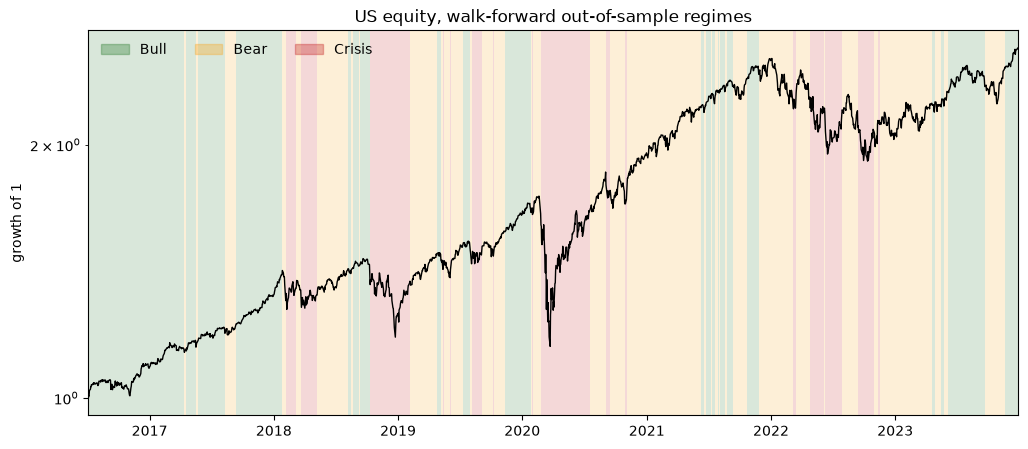

In [9]:
level = np.exp(master["equity_ret"].cumsum()).loc[oos]
ax = regime_overlay(level / level.iloc[0], regimes)
ax.set_title("US equity, walk-forward out-of-sample regimes");

The overlay is the encouraging part: with no future information the filter independently flags
Feb 2018, Q4 2018, COVID and 2022. The regime detector works. It is the leap from *volatile* to
*sell* that does not.

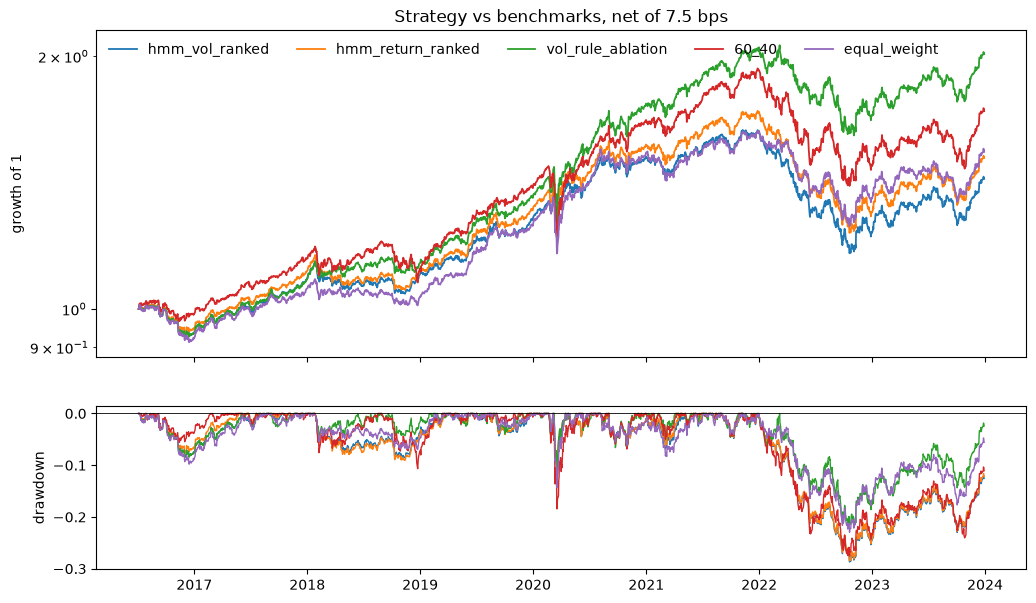

In [10]:
axes = equity_drawdown(books)
axes[0].set_title(f"Strategy vs benchmarks, net of {cfg.costs_bps} bps");

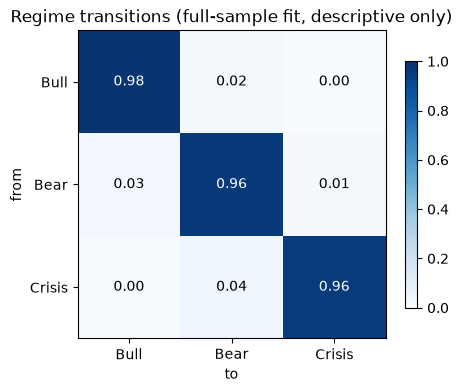

In [11]:
model = RegimeModel(n_states=cfg.hmm.n_states, covariance_type=cfg.hmm.covariance_type,
                    n_iter=cfg.hmm.n_iter, tol=cfg.hmm.tol, random_state=cfg.seed
                    ).fit(scaled, rank_by=feats["vol_21"].to_numpy())
ax = transition_heatmap(model.transition_matrix())
ax.set_title("Regime transitions (full-sample fit, descriptive only)");

## Conclusion

The engine is sound and the regimes are real: persistent (diagonal 0.96-0.98), economically legible
(VIX 13 / 19 / 28), and detected without lookahead. The strategy still fails, for a reason worth
stating plainly - **volatility regimes are not return regimes**. A state variable has to predict
direction before a directional bet on it can pay, and this one predicts variance.

Two honest directions from here, neither of which is "search until the Sharpe looks good":

1. Keep the states, change the bet. If the model predicts variance, target constant *risk* rather
   than de-risking. That is volatility targeting, a different strategy with a matching premise.
2. Change the states. Add a feature that separates a crash from a rebound (drawdown from peak, or
   the sign of long-horizon momentum). Momentum features are already present, but a
   diagonal-covariance Gaussian latches onto the vol and VIX dimensions where the regime structure
   is strongest.

Every variant tried increments the trial count in the deflated Sharpe. At four trials the search
budget is already most of the way spent.